In [1]:
# ============================================
# Step 1: Import Required Libraries
# ============================================

import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

warnings.filterwarnings("ignore")

print("TensorFlow Version :", tf.__version__)
print("NumPy Version      :", np.__version__)

TensorFlow Version : 2.20.0
NumPy Version      : 2.0.2


In [2]:
# ============================================
# Step 2: Check GPU
# ============================================

print("Available GPUs:")
print(tf.config.list_physical_devices("GPU"))

if tf.config.list_physical_devices("GPU"):
    print("\n✅ GPU Enabled Successfully")
else:
    print("\n❌ GPU Not Detected")

Available GPUs:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]

✅ GPU Enabled Successfully


In [3]:
# ============================================
# Step 3: Locate Dataset
# ============================================

import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/jainam2511j
/kaggle/input/datasets/jainam2511j/pneumonia
/kaggle/input/datasets/jainam2511j/pneumonia/chest_xray
/kaggle/input/datasets/jainam2511j/pneumonia/chest_xray/chest_xray
/kaggle/input/datasets/jainam2511j/pneumonia/chest_xray/chest_xray/val
/kaggle/input/datasets/jainam2511j/pneumonia/chest_xray/chest_xray/val/PNEUMONIA
/kaggle/input/datasets/jainam2511j/pneumonia/chest_xray/chest_xray/val/NORMAL
/kaggle/input/datasets/jainam2511j/pneumonia/chest_xray/chest_xray/test
/kaggle/input/datasets/jainam2511j/pneumonia/chest_xray/chest_xray/test/PNEUMONIA
/kaggle/input/datasets/jainam2511j/pneumonia/chest_xray/chest_xray/test/NORMAL
/kaggle/input/datasets/jainam2511j/pneumonia/chest_xray/chest_xray/train
/kaggle/input/datasets/jainam2511j/pneumonia/chest_xray/chest_xray/train/PNEUMONIA
/kaggle/input/datasets/jainam2511j/pneumonia/chest_xray/chest_xray/train/NORMAL
/kaggle/input/datasets/jainam2511j/pneumonia/chest_xray/val
/

In [4]:
# ============================================
# Step 4: Verify Dataset
# ============================================

train_path = "/kaggle/input/datasets/jainam2511j/pneumonia/chest_xray/train"
val_path = "/kaggle/input/datasets/jainam2511j/pneumonia/chest_xray/val"
test_path = "/kaggle/input/datasets/jainam2511j/pneumonia/chest_xray/test"

print("Training Images")
print("----------------")
print("NORMAL     :", len(os.listdir(train_path + "/NORMAL")))
print("PNEUMONIA  :", len(os.listdir(train_path + "/PNEUMONIA")))

print("\nValidation Images")
print("----------------")
print("NORMAL     :", len(os.listdir(val_path + "/NORMAL")))
print("PNEUMONIA  :", len(os.listdir(val_path + "/PNEUMONIA")))

print("\nTesting Images")
print("----------------")
print("NORMAL     :", len(os.listdir(test_path + "/NORMAL")))
print("PNEUMONIA  :", len(os.listdir(test_path + "/PNEUMONIA")))

Training Images
----------------
NORMAL     : 1341
PNEUMONIA  : 3875

Validation Images
----------------
NORMAL     : 8
PNEUMONIA  : 8

Testing Images
----------------
NORMAL     : 234
PNEUMONIA  : 390


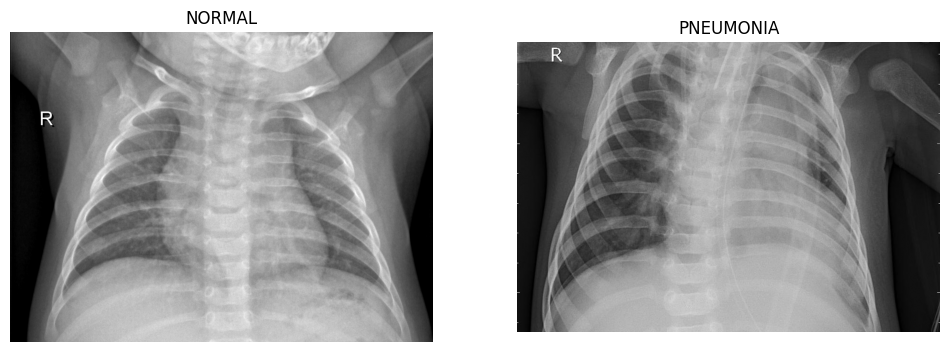

In [5]:
# ============================================
# Step 5: Display Sample Images
# ============================================

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import os

plt.figure(figsize=(12,6))

# NORMAL IMAGE
normal_dir = train_path + "/NORMAL"
normal_img = random.choice(os.listdir(normal_dir))

plt.subplot(1,2,1)
img = mpimg.imread(os.path.join(normal_dir, normal_img))
plt.imshow(img, cmap="gray")
plt.title("NORMAL")
plt.axis("off")

# PNEUMONIA IMAGE
pneumonia_dir = train_path + "/PNEUMONIA"
pneumonia_img = random.choice(os.listdir(pneumonia_dir))

plt.subplot(1,2,2)
img = mpimg.imread(os.path.join(pneumonia_dir, pneumonia_img))
plt.imshow(img, cmap="gray")
plt.title("PNEUMONIA")
plt.axis("off")

plt.show()

In [6]:
# ============================================
# Step 6: Create Training & Validation Dataset
# ============================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode="binary"
)

print("\n✅ Dataset Loaded Successfully")

Found 5216 files belonging to 2 classes.
Using 4173 files for training.


I0000 00:00:1783854384.096751      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783854384.100155      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 5216 files belonging to 2 classes.
Using 1043 files for validation.
Found 624 files belonging to 2 classes.

✅ Dataset Loaded Successfully


In [7]:
# ============================================
# Step 7: Dataset Information
# ============================================

print("Class Names:", train_dataset.class_names)

print("\nTraining Batches   :", len(train_dataset))
print("Validation Batches :", len(validation_dataset))
print("Testing Batches    :", len(test_dataset))

Class Names: ['NORMAL', 'PNEUMONIA']

Training Batches   : 131
Validation Batches : 33
Testing Batches    : 20


In [8]:
# ============================================
# Step 8: Optimize Dataset Pipeline
# ============================================

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = (
    train_dataset
    .cache()
    .shuffle(1000)
    .prefetch(buffer_size=AUTOTUNE)
)

validation_dataset = (
    validation_dataset
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

test_dataset = (
    test_dataset
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

print("✅ Dataset pipeline optimized successfully.")

✅ Dataset pipeline optimized successfully.


In [9]:
# ============================================
# Step 9: Data Augmentation
# ============================================

data_augmentation = tf.keras.Sequential([

    layers.RandomRotation(0.05),

    layers.RandomZoom(
        height_factor=0.10,
        width_factor=0.10
    ),

    layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    ),

    layers.RandomContrast(0.10),

], name="data_augmentation")

print("✅ Data Augmentation Pipeline Created")

✅ Data Augmentation Pipeline Created


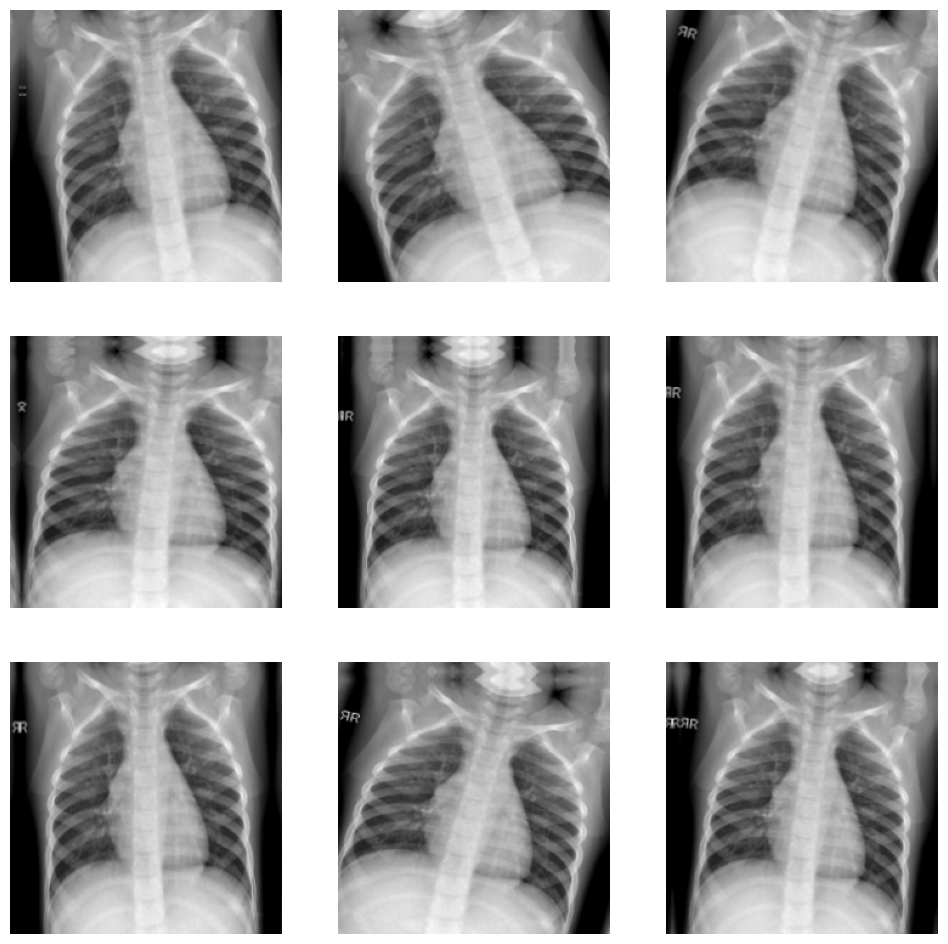

In [10]:
# ============================================
# Step 10: Visualize Data Augmentation
# ============================================

plt.figure(figsize=(12,12))

for images, labels in train_dataset.take(1):

    first_image = images[0]

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        augmented_image = data_augmentation(
            tf.expand_dims(first_image, 0)
        )

        plt.imshow(
            augmented_image[0].numpy().astype("uint8")
        )

        plt.axis("off")

plt.show()

In [11]:
# ============================================
# Step 11: Build DenseNet121 Model
# ============================================

base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the pretrained DenseNet layers
base_model.trainable = False

print("✅ DenseNet121 Loaded Successfully")
print("Trainable:", base_model.trainable)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ DenseNet121 Loaded Successfully
Trainable: False


In [12]:
# ============================================
# Step 12: Build Complete Model
# ============================================

inputs = tf.keras.Input(shape=(224, 224, 3))

# Data Augmentation
x = data_augmentation(inputs)

# DenseNet Preprocessing
x = preprocess_input(x)

# Feature Extraction
x = base_model(x, training=False)

# Classification Head
x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.4)(x)

x = layers.Dense(
    128,
    activation="relu"
)(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    1,
    activation="sigmoid"
)(x)

model = tf.keras.Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,173,441 (27.36 MB)

 Trainable params: 133,633 (522.00 KB)

 Non-trainable params: 7,039,808 (26.85 MB)

In [13]:
# ============================================
# Step 13: Compile Model
# ============================================

optimizer = tf.keras.optimizers.AdamW(
    learning_rate=1e-4,
    weight_decay=1e-4
)

model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

print("✅ Model Compiled Successfully")

✅ Model Compiled Successfully


In [14]:
# ============================================
# Step 14: Compute Class Weights
# ============================================

from sklearn.utils.class_weight import compute_class_weight

# Collect labels from the training dataset
train_labels = []

for _, labels in train_dataset.unbatch():
    train_labels.append(int(labels.numpy()))

train_labels = np.array(train_labels)

# Compute class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weight_dict = {
    0: class_weights[0],   # NORMAL
    1: class_weights[1]    # PNEUMONIA
}

print("Class Weights:")
print(class_weight_dict)

Class Weights:
{0: np.float64(1.9107142857142858), 1: np.float64(0.6772151898734177)}


In [15]:
# ============================================
# Step 15: Training Callbacks
# ============================================

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_pneumonia_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

callbacks = [
    early_stopping,
    reduce_lr,
    checkpoint
]

print("✅ Callbacks Created Successfully")

✅ Callbacks Created Successfully


In [16]:
# ============================================
# Step 16: Train the Model (Phase 1)
# ============================================

EPOCHS = 20

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.6150 - auc: 0.6969 - loss: 0.7132 - precision: 0.8417 - recall: 0.5926
Epoch 1: val_accuracy improved from None to 0.78619, saving model to best_pneumonia_model.keras

Epoch 1: finished saving model to best_pneumonia_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 50s 237ms/step - accuracy: 0.6949 - auc: 0.8201 - loss: 0.5614 - precision: 0.9094 - recall: 0.6517 - val_accuracy: 0.7862 - val_auc: 0.9596 - val_loss: 0.4624 - val_precision: 0.9847 - val_recall: 0.7305 - learning_rate: 1.0000e-04
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.8033 - auc: 0.9359 - loss: 0.3693 - precision: 0.9709 - recall: 0.7561
Epoch 2: val_accuracy improved from 0.78619 to 0.88974, saving model to best_pneumonia_model.keras

Epoch 2: finished saving model to best_pneumonia_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 24s 179ms/step - accuracy: 0.8176 - auc: 0.9468 - loss: 0.3444 - precision: 0.9785 - recall: 0.7699 - val_accura

In [17]:
# ============================================
# Step 17: Fine-Tuning Setup
# ============================================

# Unfreeze the DenseNet model
base_model.trainable = True

# Freeze all layers except the last 40
for layer in base_model.layers[:-40]:
    layer.trainable = False

print("Trainable Layers:")

count = 0

for layer in base_model.layers:
    if layer.trainable:
        count += 1

print(count)

Trainable Layers:
40


In [18]:
# ============================================
# Step 18: Recompile for Fine-Tuning
# ============================================

fine_tune_optimizer = tf.keras.optimizers.AdamW(
    learning_rate=1e-5,      # 10x smaller learning rate
    weight_decay=1e-5
)

model.compile(
    optimizer=fine_tune_optimizer,
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

print("✅ Model Recompiled for Fine-Tuning")

✅ Model Recompiled for Fine-Tuning


In [19]:
# ============================================
# Step 19: Fine-Tune the Model
# ============================================

FINE_TUNE_EPOCHS = 10

history_fine = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.8611 - auc: 0.9576 - loss: 0.2910 - precision: 0.9751 - recall: 0.8298
Epoch 1: val_accuracy did not improve from 0.91179
131/131 ━━━━━━━━━━━━━━━━━━━━ 50s 230ms/step - accuracy: 0.8531 - auc: 0.9578 - loss: 0.2961 - precision: 0.9772 - recall: 0.8202 - val_accuracy: 0.9003 - val_auc: 0.9811 - val_loss: 0.2816 - val_precision: 0.9929 - val_recall: 0.8753 - learning_rate: 1.0000e-05
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.8490 - auc: 0.9638 - loss: 0.2844 - precision: 0.9826 - recall: 0.8113
Epoch 2: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.

Epoch 2: val_accuracy did not improve from 0.91179
131/131 ━━━━━━━━━━━━━━━━━━━━ 26s 197ms/step - accuracy: 0.8670 - auc: 0.9679 - loss: 0.2639 - precision: 0.9828 - recall: 0.8345 - val_accuracy: 0.8840 - val_auc: 0.9806 - val_loss: 0.3140 - val_precision: 0.9927 - val_recall: 0.8539 - learning_rate: 1.0000e-05
Epoch 3/10
131/131

In [20]:
# ============================================
# Step 20: Evaluate on Test Dataset
# ============================================

test_results = model.evaluate(
    test_dataset,
    verbose=1
)

print("\n========== Test Results ==========")
print(f"Test Loss      : {test_results[0]:.4f}")
print(f"Test Accuracy  : {test_results[1]*100:.2f}%")
print(f"Test Precision : {test_results[2]*100:.2f}%")
print(f"Test Recall    : {test_results[3]*100:.2f}%")
print(f"Test AUC       : {test_results[4]*100:.2f}%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 209ms/step - accuracy: 0.8862 - auc: 0.9469 - loss: 0.2918 - precision: 0.9038 - recall: 0.9154

========== Test Results ==========
Test Loss      : 0.2918
Test Accuracy  : 88.62%
Test Precision : 90.38%
Test Recall    : 91.54%
Test AUC       : 94.69%


In [21]:
# ============================================
# Step 21: Generate Predictions
# ============================================

import numpy as np

# Predict probabilities
y_prob = model.predict(test_dataset)

# Convert probabilities to class labels
y_pred = (y_prob > 0.5).astype(int).flatten()

# Extract true labels
y_true = np.concatenate([
    labels.numpy() for images, labels in test_dataset
]).astype(int)

print("Predictions Generated Successfully")
print("Number of Test Images:", len(y_true))

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 338ms/step
Predictions Generated Successfully
Number of Test Images: 624


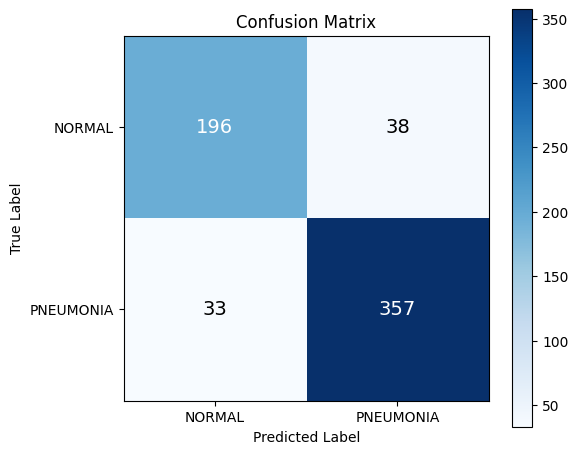

Confusion Matrix:
[[196  38]
 [ 33 357]]


In [22]:
# ============================================
# Step 22: Confusion Matrix
# ============================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

plt.imshow(cm, interpolation="nearest", cmap="Blues")

plt.title("Confusion Matrix")
plt.colorbar()

classes = ["NORMAL", "PNEUMONIA"]
tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="white" if cm[i, j] > cm.max()/2 else "black",
            fontsize=14
        )

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

print("Confusion Matrix:")
print(cm)

In [23]:
# ============================================
# Step 23: Classification Report
# ============================================

from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["NORMAL", "PNEUMONIA"]
    )
)

              precision    recall  f1-score   support

      NORMAL       0.86      0.84      0.85       234
   PNEUMONIA       0.90      0.92      0.91       390

    accuracy                           0.89       624
   macro avg       0.88      0.88      0.88       624
weighted avg       0.89      0.89      0.89       624



In [24]:
# ============================================
# Step 24: Save Final Model
# ============================================

model.save("pneumonia_model.keras")

print("✅ Model saved successfully!")

✅ Model saved successfully!
